In [1]:
import json
import os
import sys
import hashlib
from pathlib import Path
from datetime import datetime

import ipynbname
import wandb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dotenv import load_dotenv

sys.path.append(os.path.abspath("../.."))

from src.models.model_registry import get_trainer
from src.utils.loggers import WandbLogger
from src.utils.telegram import send_message

## Create OOF and Test pred

In [2]:
# ===== User config =====
load_dotenv(dotenv_path="../../.env")

model_name = "lgbm"
data_id = "057"

n_trial = 21

n_folds = 5
seed = 42

In [3]:
# === get params, n_folds, seed, and batch_rows ===
study_name = f"{model_name}-{data_id}"
feature_dir = Path(f"../../artifacts/features/{data_id}")

with open(feature_dir / "meta.json", "r") as f:
    meta = json.load(f)

train_paths = meta["train_paths"]
test_paths = meta["test_paths"]
level = meta["level"]

# get params
params_id = f"trl{n_trial}"
params_path = f"../../artifacts/optuna/{study_name}/{params_id}.json"

with open(params_path, "r") as f:
    manifest = json.load(f)

params = manifest["params"]
opts = manifest["opts"]

print("Manifest path: ", params_path)
print("Params:\n", params)
print("opts: ", opts)

Manifest path:  ../../artifacts/optuna/lgbm-057/trl21.json
Params:
 {'learning_rate': 0.01, 'num_leaves': 970, 'min_child_samples': 362, 'min_split_gain': 0.00045914418634831735, 'feature_fraction': 0.37121824466699876, 'bagging_fraction': 0.9049166225938291, 'bagging_freq': 8, 'lambda_l1': 8.991609072217798, 'lambda_l2': 0.13082234598927622}
opts:  {}


In [4]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))

run = wandb.init(
    project=wandb_project,
    group=study_name,
    name=params_id,
    job_type="cv_training",
    tags=[model_name, level],
    config={
        "data_id": data_id,
        "n_folds": n_folds,
        "level": level,
        "model": model_name,
        "seed": seed,
        **params,
        **opts
    },
    dir="../../artifacts",
    reinit="finish_previous"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/hanse/.netrc
wandb: Currently logged in as: kaitookano (kaitookano-waseda-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# === Training ===
trainer_class = get_trainer(model_name)
trainer = trainer_class(
    data_id,
    train_paths,
    test_paths,
    features=None,
    target="target",
    fold_col=None,
    weight_col=None,
    cat_cols=None,
    params=params,
    n_folds=n_folds,
    seed=seed,
    gpu=True,
    opts=opts
)

result = trainer.fit(
    loggers=[WandbLogger(run=run)]
)

Fold Col: 5fold-s42
================== Fold 1 / 5 ==================
Free CPU Mem: 11.57 GB
Free GPU Mem: 6.89 GB
Training until validation scores don't improve for 1000 rounds
[100]	train's auc: 0.974274	eval's auc: 0.972672
[200]	train's auc: 0.976169	eval's auc: 0.973814
[300]	train's auc: 0.978012	eval's auc: 0.974713
[400]	train's auc: 0.979751	eval's auc: 0.975387
[500]	train's auc: 0.981379	eval's auc: 0.975877
[600]	train's auc: 0.982922	eval's auc: 0.97619
[700]	train's auc: 0.984391	eval's auc: 0.976422
[800]	train's auc: 0.985785	eval's auc: 0.976607
[900]	train's auc: 0.987084	eval's auc: 0.976735
[1000]	train's auc: 0.988325	eval's auc: 0.976834
[1100]	train's auc: 0.989424	eval's auc: 0.976922
[1200]	train's auc: 0.99045	eval's auc: 0.976974
[1300]	train's auc: 0.991378	eval's auc: 0.977024
[1400]	train's auc: 0.992232	eval's auc: 0.977063
[1500]	train's auc: 0.992988	eval's auc: 0.977083
[1600]	train's auc: 0.993684	eval's auc: 0.97711
[1700]	train's auc: 0.99431	eval's 

eval/f1/auc,▁▄▅▆▆▇▇▇▇███████████████████████████████
eval/f2/auc,▁▁▃▃▅▆▆▇▇▇▇█████████████████████████████
eval/f3/auc,▁▂▃▃▃▄▆▆▆▆▇▇▇▇▇▇▇▇▇█████████████████████
eval/f4/auc,▁▃▃▃▆▆▆▇▇▇▇▇▇███████████████████████████
eval/f5/auc,▁▂▄▅▇▇▇▇▇▇▇▇████████████████████████████
iter_f1,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
iter_f2,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
iter_f3,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
iter_f4,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇██
iter_f5,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▆▆▆▆▇▇▇▇▇█████
train/f1/auc,▁▁▁▂▂▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████


In [6]:
# ===== Save Manifest, OOF, and Test pred=====
runs_root = Path("../../runs")
run_id = f"{model_name}-{data_id}-{params_id}-{n_folds}fold-s{seed}"
run_dir = runs_root / run_id
run_dir.mkdir(parents=True, exist_ok=True)

s = json.dumps(params, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
phash = hashlib.sha256(s.encode()).hexdigest()[:10]

manifest = {
    "run_id": run_id,
    "wandb_id": run.id,
    "wandb_url": run.url,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": model_name,
    "data_id": data_id,
    "n_folds": n_folds,
    "seed": seed,
    "feature_dir": str(feature_dir.resolve()),
    "phash": phash,
    "param_source": params_path,
    "params": params,
    "run_dir": str(run_dir.resolve()),
    "cv_score": float(result["oof_score"]),
    "submission": {
        "competition": None,
        "ref": None,
        "file": None,
        "public_score": None,
        "private_score": None,
        "submitted_at": None
    }
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)

print("manifest saved", run_dir / "manifest.json")

# save oof and test pred
np.save(run_dir / "oof.npy", result["oof"])
np.save(run_dir / "test.npy", result["test_pred"])

# save notebook as html
nb_path = ipynbname.path()
stem = nb_path.stem
!jupyter nbconvert --to html "{nb_path}" --output "{stem}" --output-dir "{run_dir}"

print(f"oof and test preds saved successfully in:\n{run_dir}")
send_message(
    f"✅ Finished CV for {run_id}!"
    f"\nScore: {round(result['oof_score'], 5)}"
)

manifest saved ../../runs/lgbm-057-trl21-5fold-s42/manifest.json
[NbConvertApp] Converting notebook /home/hanse/kaggle/binary-bank/notebooks/training/02_gpu_cv.ipynb to html
[NbConvertApp] Writing 330688 bytes to ../../runs/lgbm-057-trl21-5fold-s42/02_gpu_cv.html
oof and test preds saved successfully in:
../../runs/lgbm-057-trl21-5fold-s42
✅ Message sent.


## Check Feature Importance (Only XGB or LGBM)

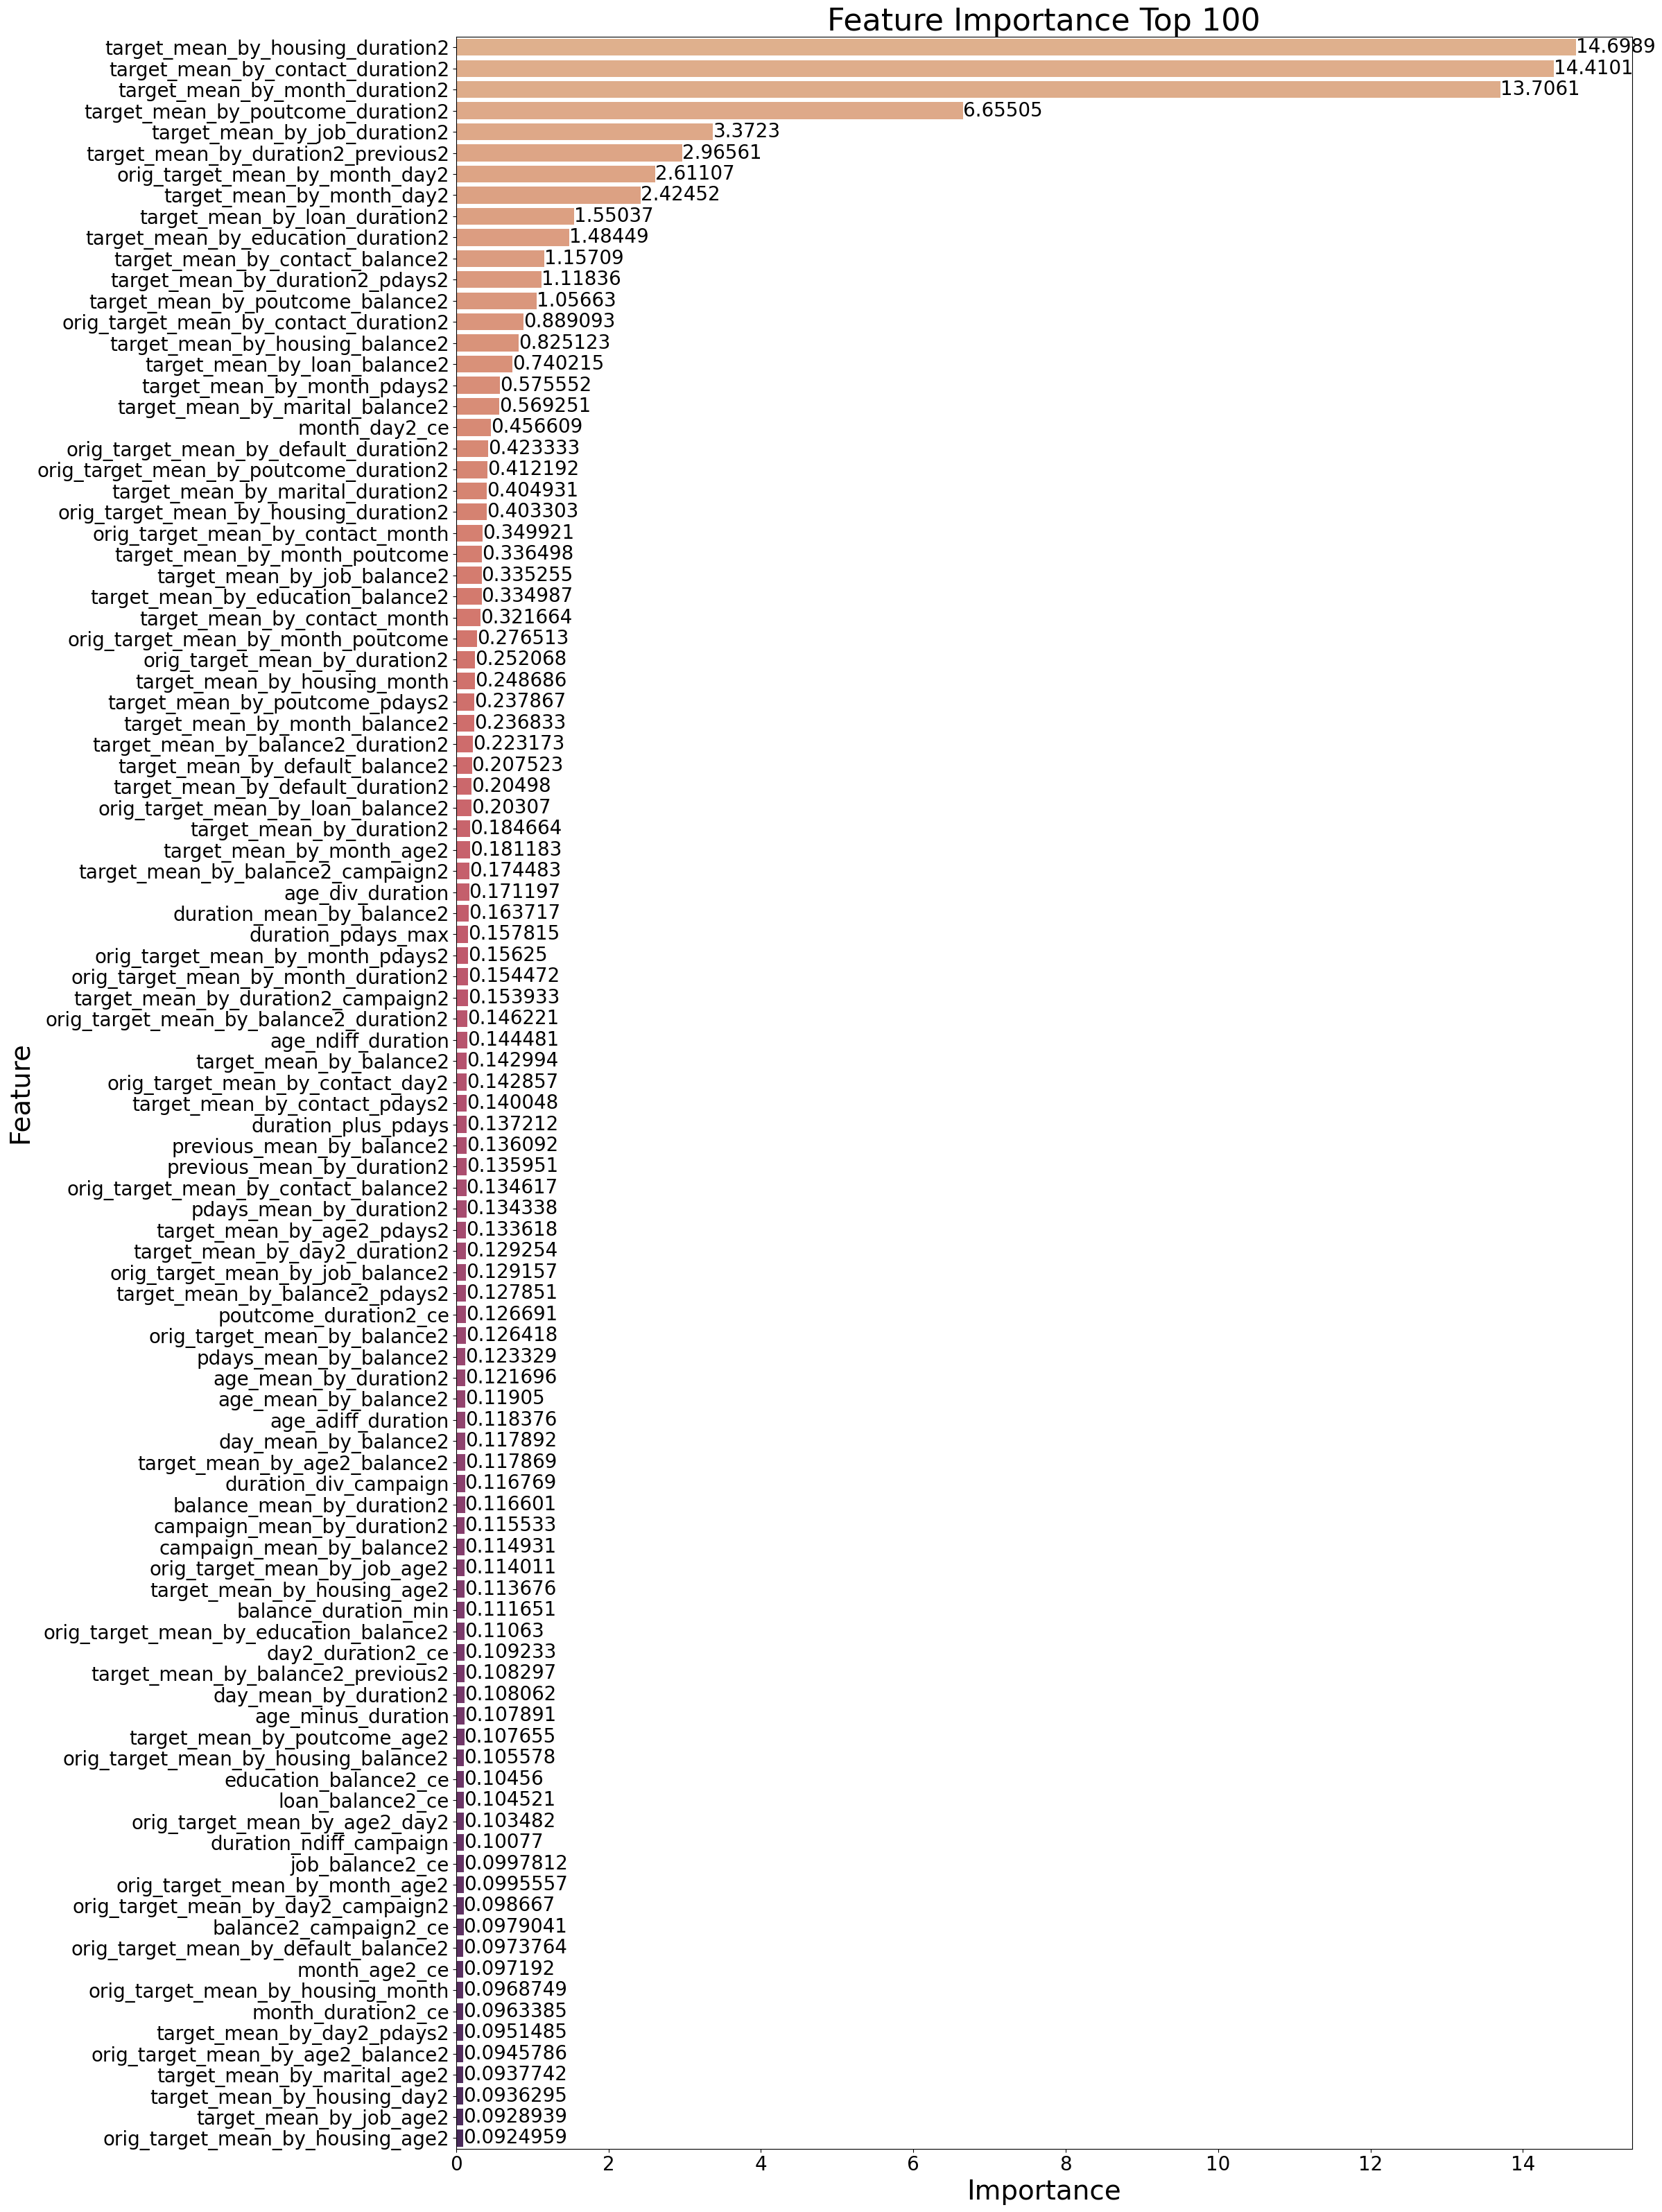

FI graph saved successfully to ../../runs/lgbm-057-trl21-5fold-s42


In [16]:
# Plot feature importance and get top columns
df = result["fi_mean"].to_pandas().rename(columns={"mean_ratio": "Importance"})
df_top100 = df[:100]

fig, ax = plt.subplots(figsize=(24, 32))
sns.barplot(
    data=df_top100,
    y="Feature",
    x="Importance",
    orient="h",
    palette="flare",
    hue="Feature",
    ax=ax
)
for container in ax.containers:
    labels = ax.bar_label(container)
    for label in labels:
        label.set_fontsize(20)
plt.title("Feature Importance Top 100", fontsize=32)
plt.xlabel("Importance", fontsize=28)
plt.ylabel("Feature", fontsize=28)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
plt.tight_layout()

fig.savefig(run_dir / "feature_importance.png", dpi=200, bbox_inches="tight")
fig.savefig(run_dir / "feature_importance.svg", bbox_inches="tight")

plt.show()

print(f"FI graph saved successfully to {run_dir}")

In [17]:
thresholds = [0.90, 0.95, 0.99]

# 重要度の並びを安定化（同率時はFeature名で昇順）
df = df.sort_values(["Importance", "Feature"], ascending=[False, True], ignore_index=True)

total = df["Importance"].sum()
print("Contributed cols (nonzero in df):", len(df))

keep_dict = {}
for th in thresholds:
    # この閾値でどこまで採用するか（しきい値を超える要素も1つ含める）
    limit = th * total
    cum = df["Importance"].cumsum()
    k = int((cum <= limit).sum())
    if k < len(df):
        k += 1

    keep_cols = df["Feature"].iloc[:k].tolist()
    importance = df["Importance"].iloc[:k].to_list()
    cover = float(cum.iloc[k-1] / total) if total > 0 and k > 0 else 0.0

    print(f"\nThreshold {th:.2f} → Keep {k} cols (coverage={cover:.4f})")
    keep_dict[f"{th:.2f}"] = {
        "k": k,
        "coverage": cover,
        "cols": keep_cols,
        "importance": importance
    }

# 保存
path_keep = run_dir / "keep_cols.json"
with open(path_keep, "w", encoding="utf-8") as f:
    json.dump(keep_dict, f, ensure_ascii=False, indent=4)
print(f"saved: {path_keep}")

# resave notebook as html
nb_path = ipynbname.path()
stem = nb_path.stem
!jupyter nbconvert --to html "{nb_path}" --output "{stem}" --output-dir "{run_dir}"

Contributed cols (nonzero in df): 623

Threshold 0.90 → Keep 173 cols (coverage=0.9002)

Threshold 0.95 → Keep 266 cols (coverage=0.9502)

Threshold 0.99 → Keep 423 cols (coverage=0.9901)
saved: ../../runs/lgbm-057-trl21-5fold-s42/keep_cols.json
[NbConvertApp] Converting notebook /home/hanse/kaggle/binary-bank/notebooks/training/02_gpu_cv.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 395406 bytes to ../../runs/lgbm-057-trl21-5fold-s42/02_gpu_cv.html
